# COCO Global + Chip OOD Fusion

Focused research notebook for combining whole-image OOD scores with object/chip-level ViM scores on COCO vs COCO-O.

The goal is to separate three signals: global image embedding distance, pooled chip OOD scores, and optional scene geometry.

In [19]:
from __future__ import annotations

import contextlib
import io
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torchvision.datasets.folder import default_loader

# --- Edit these paths for your machine, or set OODKIT_DATASETS ---------------
DATASETS_ROOT = Path(os.environ.get("OODKIT_DATASETS", "/datasets"))
COCO_ROOT = DATASETS_ROOT / "coco"
COCO_O_ROOT = DATASETS_ROOT / "coco_ood"

BACKBONE = "dinov2-small"
HEAD_EPOCHS = 3
BATCH_SIZE = 64
IMAGE_BATCH_SIZE = 64
NUM_WORKERS = 4
PIN_MEMORY = True
PERSISTENT_WORKERS = True

SEED = 42
MIN_BOX_SIDE = 0
MIN_CHIP_SIZE = 25
TRAIN_IMAGE_FRACTION = 0.2
VAL_IMAGE_FRACTION = 0.5
OOD_IMAGE_FRACTION = 1.0
OOD_DOMAINS = ["cartoon", "tattoo", "weather"]

POOL_TOPK = 3
GLOBAL_METHOD = "Mahalanobis"  # one of: "KNN", "Mahalanobis", "WDiscOOD"
GLOBAL_KNN_K = 10
GEOMETRY_FUSION_WEIGHT = 0.25
RANK_TOP_K = 8

_DL_KW = dict(
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
)


def _check_paths() -> None:
    missing = [p for p in (COCO_ROOT, COCO_O_ROOT) if not p.exists()]
    if missing:
        print("Missing paths - set OODKIT_DATASETS or update constants:", file=sys.stderr)
        for p in missing:
            print(f"  - {p}", file=sys.stderr)
        raise FileNotFoundError("Fix COCO_ROOT and COCO_O_ROOT.")


_check_paths()


In [2]:
from oodkit.contrib.coco import (
    CocoCategoryTable,
    coco_chip_dataset,
    coco_ood_chip_datasets,
    discover_coco_id,
)
from oodkit.data.chip_dataset import ChipDataset
from oodkit.detectors import KNN, Mahalanobis, ViM, WDiscOOD
from oodkit.embeddings.backbones import load_backbone
from oodkit.embeddings.embedder import Embedder
from oodkit.evaluation import (
    GeometryAwarePooler,
    ScoreBank,
    auroc,
    concatenate_embedding_results,
    evaluate,
    pool_image_scores,
)


In [3]:
def _subsample_by_image(ds: ChipDataset, fraction: float, seed: int, *, id_group: str | None = None):
    """Keep a random subset of source images while preserving chip metadata."""
    if fraction >= 1.0:
        return _ChipSubset(ds, list(range(len(ds))), id_group=id_group)
    rng = np.random.default_rng(seed)
    available = np.unique(ds.chip_to_image)
    n_images = len(available)
    k = max(1, int(n_images * fraction))
    keep = np.sort(rng.choice(available, size=k, replace=False))
    keep_set = set(int(i) for i in keep)
    chip_mask = np.array([int(i) in keep_set for i in ds.chip_to_image], dtype=bool)
    return _ChipSubset(ds, np.nonzero(chip_mask)[0].tolist(), id_group=id_group)


class _ChipSubset(torch.utils.data.Dataset):
    """Subset wrapper that forwards metadata needed by extraction and pooling."""

    def __init__(self, base: ChipDataset, idx: list[int], *, id_group: str | None = None) -> None:
        self.base = base
        self.idx = idx
        raw_c2i = base.chip_to_image[idx]
        kept_images, dense = np.unique(raw_c2i, return_inverse=True)
        self.chip_to_image = dense.astype(np.int64)
        self.image_paths = [base.image_paths[int(i)] for i in kept_images]
        self.boxes = base.boxes[idx]
        self.labels = base.labels[idx] if base.labels is not None else None
        self.object_ids = base.object_ids[idx]
        self.image_ids = base.image_ids[idx]
        self.image_sizes = base.image_sizes[idx] if base.image_sizes is not None else None
        if base.groups is not None:
            self.groups = base.groups[idx]
        elif id_group is not None:
            self.groups = np.array([id_group] * len(idx), dtype=object)
        else:
            self.groups = None
        if hasattr(base, "classes"):
            self.classes = base.classes
        parent_paths = [self.image_paths[int(i)] for i in self.chip_to_image]
        if self.labels is not None:
            self.imgs = list(zip(parent_paths, self.labels.tolist()))
            self.targets = self.labels.tolist()
        else:
            self.imgs = [(p, -1) for p in parent_paths]

    def __len__(self) -> int:
        return len(self.idx)

    def __getitem__(self, i: int):
        return self.base[self.idx[i]]


class _ImagePathDataset(torch.utils.data.Dataset):
    """Whole-image dataset using the same processor as the chip pipeline."""

    def __init__(self, image_paths, processor, *, image_mode="RGB") -> None:
        self.image_paths = [str(p) for p in image_paths]
        self.processor = processor
        self.image_mode = image_mode

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, i: int):
        image = default_loader(self.image_paths[i])
        if self.image_mode is not None and image.mode != self.image_mode:
            image = image.convert(self.image_mode)
        return self.processor(images=image, return_tensors="pt")["pixel_values"].squeeze(0)


In [4]:
def _image_values_from_chips(chip_to_image, values, n_images, *, default=None):
    out = [default] * n_images
    for chip_idx, image_idx in enumerate(chip_to_image):
        out[int(image_idx)] = values[chip_idx]
    return out


def _majority_label_per_image(chip_to_image, labels, n_images):
    labels = np.asarray(labels, dtype=np.int64)
    out = np.zeros(n_images, dtype=np.int64)
    for image_idx in range(n_images):
        vals = labels[np.asarray(chip_to_image) == image_idx]
        if vals.size == 0:
            continue
        uniq, counts = np.unique(vals, return_counts=True)
        out[image_idx] = int(uniq[np.argmax(counts)])
    return out


def _zscore_on_id(scores, id_mask, *, eps=1e-12):
    scores = np.asarray(scores, dtype=np.float64)
    out = np.full_like(scores, np.nan, dtype=np.float64)
    fit_mask = id_mask & np.isfinite(scores)
    if not np.any(fit_mask):
        raise ValueError("cannot z-score without finite ID scores")
    mean = float(np.mean(scores[fit_mask]))
    std = float(np.std(scores[fit_mask]))
    if std <= eps:
        std = 1.0
    mask = np.isfinite(scores)
    out[mask] = (scores[mask] - mean) / std
    return out


def _score_table(scores_by_name, labels, groups, mask):
    bank = ScoreBank(ood_labels=labels[mask], groups=groups[mask])
    for name, scores in scores_by_name.items():
        bank.add(name, np.asarray(scores)[mask])
    print(evaluate(bank))


def _safe_add(*arrays):
    out = np.zeros_like(np.asarray(arrays[0], dtype=np.float64))
    mask = np.ones(out.shape, dtype=bool)
    for arr in arrays:
        arr = np.asarray(arr, dtype=np.float64)
        mask &= np.isfinite(arr)
        out += np.where(np.isfinite(arr), arr, 0.0)
    out[~mask] = np.nan
    return out


## Load COCO chips

This mirrors the COCO-O chip setup, but the notebook will also extract embeddings from the parent full images.

In [5]:
_, processor, _ = load_backbone(BACKBONE)

coco_paths = discover_coco_id(COCO_ROOT)
category_table = CocoCategoryTable.from_coco_json(coco_paths.train_ann)
print(f"COCO classes: {category_table.num_classes}")

train_full = coco_chip_dataset(
    coco_paths.train_ann,
    coco_paths.train_images,
    processor,
    category_table=category_table,
    min_chip_size=MIN_CHIP_SIZE,
    min_box_side=MIN_BOX_SIDE,
)
val_full = coco_chip_dataset(
    coco_paths.val_ann,
    coco_paths.val_images,
    processor,
    category_table=category_table,
    min_chip_size=MIN_CHIP_SIZE,
    min_box_side=MIN_BOX_SIDE,
)
ood_full = coco_ood_chip_datasets(
    COCO_O_ROOT,
    processor,
    category_table=category_table,
    only=OOD_DOMAINS,
    min_chip_size=MIN_CHIP_SIZE,
    min_box_side=MIN_BOX_SIDE,
)

train_ds = _subsample_by_image(train_full, TRAIN_IMAGE_FRACTION, SEED, id_group="id_train")
val_ds = _subsample_by_image(val_full, VAL_IMAGE_FRACTION, SEED + 1, id_group="id")
ood_ds = {
    name: _subsample_by_image(ds, OOD_IMAGE_FRACTION, SEED + 10 + i)
    for i, (name, ds) in enumerate(ood_full.items())
}

print(f"Train chips={len(train_ds)}  train images={len(train_ds.image_paths)}")
print(f"Val chips={len(val_ds)}  val images={len(val_ds.image_paths)}")
for name, ds in ood_ds.items():
    print(f"{name}: chips={len(ds)}  images={len(ds.image_paths)}")


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

COCO classes: 80
Train chips=168549  train images=23453
Val chips=18466  val images=2476
cartoon: chips=8774  images=1996
tattoo: chips=1489  images=918
weather: chips=4509  images=961


## Train chip head and extract chip embeddings


In [6]:
embedder = Embedder(backbone=BACKBONE)
embedder.fit(
    train_ds,
    mode="head",
    epochs=HEAD_EPOCHS,
    batch_size=BATCH_SIZE,
    lr=1e-3,
    save=False,
    **_DL_KW,
)


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

training (head):   0%|          | 0/3 [00:00<?, ?it/s]

batches:   0%|          | 0/2634 [-00:00<?, ?it/s]

batches:   0%|          | 0/2634 [00:00<?, ?it/s]

batches:   0%|          | 0/2634 [00:00<?, ?it/s]

In [31]:
with warnings.catch_warnings(), contextlib.redirect_stderr(io.StringIO()):
    warnings.simplefilter("ignore")
    train_res = embedder.extract(train_ds, batch_size=BATCH_SIZE, **_DL_KW)
    val_res = embedder.extract(val_ds, batch_size=BATCH_SIZE, **_DL_KW)
    ood_res = {
        name: embedder.extract(ds, batch_size=BATCH_SIZE, **_DL_KW)
        for name, ds in ood_ds.items()
    }

assert train_res.logits is not None and train_res.labels is not None
combined, ood_labels = concatenate_embedding_results(
    [val_res, *ood_res.values()],
    [0, *[1] * len(ood_res)],
)

id_train_feat = train_res.to_features()
comb_feat = combined.to_features()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

print(f"Combined chips={combined.embeddings.shape[0]}  ood_labels={ood_labels.shape}")
print(f"Combined images={int(np.max(combined.metadata['chip_to_image'])) + 1}")


extracting:   0%|          | 0/2634 [00:00<?, ?it/s]

extracting:   0%|          | 0/289 [00:00<?, ?it/s]

extracting:   0%|          | 0/138 [00:00<?, ?it/s]

extracting:   0%|          | 0/24 [00:00<?, ?it/s]

extracting:   0%|          | 0/71 [00:00<?, ?it/s]

Combined chips=33238  ood_labels=(33238,)
Combined images=6351


## Chip-level ViM, image pooling, and geometry


In [32]:
head = embedder._head  # noqa: SLF001 - notebook research workflow
assert head is not None
W = head.weight.detach().cpu().numpy()
b = head.bias.detach().cpu().numpy()

# Logit-aware chip detector.
vim = ViM(W, b)
vim.fit(id_train_feat)
train_chip_scores = vim.score(id_train_feat)
combined_chip_scores = vim.score(comb_feat)

# Embedding-distance chip detector, included to separate detector choice from chip/global granularity.
chip_mahal = Mahalanobis()
chip_mahal.fit(id_train_feat, train_res.labels)
train_chip_mahal_scores = chip_mahal.score(id_train_feat)
combined_chip_mahal_scores = chip_mahal.score(comb_feat)

del id_train_feat, comb_feat, W, b


In [33]:
train_c2i = np.asarray(train_res.metadata["chip_to_image"], dtype=np.int64)
train_boxes = np.asarray(train_res.metadata["boxes"], dtype=np.float64)
train_sizes = np.asarray(train_res.metadata["image_sizes"], dtype=np.float64)
train_classes = np.asarray(train_res.labels, dtype=np.int64)
train_n_images = int(train_c2i.max()) + 1

chip_to_image = np.asarray(combined.metadata["chip_to_image"], dtype=np.int64)
boxes = np.asarray(combined.metadata["boxes"], dtype=np.float64)
image_sizes = np.asarray(combined.metadata["image_sizes"], dtype=np.float64)
class_labels = np.asarray(combined.labels, dtype=np.int64)
n_images = int(chip_to_image.max()) + 1

chip_mean_scores = pool_image_scores(combined_chip_scores, chip_to_image, method="mean", n_images=n_images)
chip_topk_scores = pool_image_scores(
    combined_chip_scores,
    chip_to_image,
    method="topk_mean",
    k=POOL_TOPK,
    n_images=n_images,
)
chip_mahal_mean_scores = pool_image_scores(
    combined_chip_mahal_scores,
    chip_to_image,
    method="mean",
    n_images=n_images,
)
chip_mahal_topk_scores = pool_image_scores(
    combined_chip_mahal_scores,
    chip_to_image,
    method="topk_mean",
    k=POOL_TOPK,
    n_images=n_images,
)

geom_pooler = GeometryAwarePooler(node_pool_method="topk_mean", k=POOL_TOPK)
geom_pooler.fit(train_chip_scores, train_c2i, train_boxes, train_classes, train_sizes)
geometry_scores, geometry_components = geom_pooler.score(
    combined_chip_scores,
    chip_to_image,
    boxes,
    class_labels,
    image_sizes,
    n_images=n_images,
    return_components=True,
)


In [34]:
image_ood_labels = np.zeros(n_images, dtype=np.int64)
np.maximum.at(image_ood_labels, chip_to_image, ood_labels.astype(np.int64))

group_per_chip = np.asarray(combined.metadata["group"], dtype=object)
image_group = np.empty(n_images, dtype=object)
image_group[:] = "id"
image_group[chip_to_image] = group_per_chip

image_paths = _image_values_from_chips(chip_to_image, combined.metadata["image_paths"], n_images)
image_ids = _image_values_from_chips(chip_to_image, combined.metadata["image_ids"], n_images)
image_object_count = np.bincount(chip_to_image, minlength=n_images)
id_eval_mask = image_group == "id"

valid = (
    np.isfinite(chip_mean_scores)
    & np.isfinite(chip_topk_scores)
    & np.isfinite(chip_mahal_mean_scores)
    & np.isfinite(chip_mahal_topk_scores)
    & np.isfinite(geometry_scores)
)

chip_bank = ScoreBank(ood_labels=image_ood_labels[valid], groups=image_group[valid])
chip_bank.add("chip mean ViM", chip_mean_scores[valid])
chip_bank.add(f"chip top{POOL_TOPK} ViM", chip_topk_scores[valid])
chip_bank.add("chip mean Mahalanobis", chip_mahal_mean_scores[valid])
chip_bank.add(f"chip top{POOL_TOPK} Mahalanobis", chip_mahal_topk_scores[valid])
chip_bank.add("geometry only", geometry_scores[valid])

print("Chip and geometry baselines:")
print(evaluate(chip_bank))


Chip and geometry baselines:
Detector                     AUROC     FPR@95  AUPR(OOD)   AUPR(ID)     DetErr
------------------------------------------------------------------------------
chip mean ViM               0.8759     0.6753     0.9042     0.7688     0.1777
chip top3 ViM               0.8489     0.7706     0.8908     0.7224     0.1977
chip mean Mahalanobis       0.8870     0.4943     0.8958     0.8317     0.1777
chip top3 Mahalanobis       0.8676     0.6228     0.8832     0.7895     0.1889
geometry only               0.6259     0.8473     0.7045     0.5421     0.3985


## Whole-image embeddings and non-logit global OOD


In [35]:
train_image_ds = _ImagePathDataset(train_ds.image_paths, processor)
combined_image_ds = _ImagePathDataset(image_paths, processor)

with warnings.catch_warnings(), contextlib.redirect_stderr(io.StringIO()):
    warnings.simplefilter("ignore")
    train_img_res = embedder.extract(train_image_ds, batch_size=IMAGE_BATCH_SIZE, **_DL_KW)
    combined_img_res = embedder.extract(combined_image_ds, batch_size=IMAGE_BATCH_SIZE, **_DL_KW)

train_img_feat = train_img_res.to_features()
combined_img_feat = combined_img_res.to_features()
train_image_labels = _majority_label_per_image(train_c2i, train_classes, train_n_images)

print(f"Train full images={train_img_res.embeddings.shape[0]}")
print(f"Combined full images={combined_img_res.embeddings.shape[0]}")


extracting:   0%|          | 0/367 [00:00<?, ?it/s]

extracting:   0%|          | 0/100 [00:00<?, ?it/s]

Train full images=23453
Combined full images=6351


In [36]:
global_scores_by_name = {}

knn_k = min(GLOBAL_KNN_K, train_img_res.embeddings.shape[0])
global_knn = KNN(k=knn_k)
global_knn.fit(train_img_feat)
global_scores_by_name["KNN"] = global_knn.score(combined_img_feat)

global_mahal = Mahalanobis()
global_mahal.fit(train_img_feat, train_image_labels)
global_scores_by_name["Mahalanobis"] = global_mahal.score(combined_img_feat)

if len(np.unique(train_image_labels)) >= 2:
    global_wdisc = WDiscOOD()
    global_wdisc.fit(train_img_feat, train_image_labels)
    global_scores_by_name["WDiscOOD"] = global_wdisc.score(combined_img_feat)

global_mask = valid.copy()
for scores in global_scores_by_name.values():
    global_mask &= np.isfinite(scores)

global_bank = ScoreBank(ood_labels=image_ood_labels[global_mask], groups=image_group[global_mask])
for name, scores in global_scores_by_name.items():
    global_bank.add(f"global {name}", scores[global_mask])

print("Global full-image embedding candidates:")
print(evaluate(global_bank))

if GLOBAL_METHOD not in global_scores_by_name:
    raise ValueError(f"GLOBAL_METHOD={GLOBAL_METHOD!r} not available; choose one of {sorted(global_scores_by_name)}")
global_scores = global_scores_by_name[GLOBAL_METHOD]
print(f"Using global method: {GLOBAL_METHOD}")


Global full-image embedding candidates:
Detector                  AUROC     FPR@95  AUPR(OOD)   AUPR(ID)     DetErr
---------------------------------------------------------------------------
global KNN               0.8918     0.4600     0.9041     0.8557     0.1746
global Mahalanobis       0.9099     0.4253     0.9369     0.8727     0.1625
global WDiscOOD          0.8507     0.5053     0.8782     0.8082     0.2219
Using global method: Mahalanobis


## Fusion comparison


In [37]:
fusion_valid = valid & np.isfinite(global_scores)
id_cal_mask = fusion_valid & id_eval_mask

global_z = _zscore_on_id(global_scores, id_cal_mask)
chip_mean_z = _zscore_on_id(chip_mean_scores, id_cal_mask)
chip_topk_z = _zscore_on_id(chip_topk_scores, id_cal_mask)
chip_mahal_mean_z = _zscore_on_id(chip_mahal_mean_scores, id_cal_mask)
chip_mahal_topk_z = _zscore_on_id(chip_mahal_topk_scores, id_cal_mask)
geometry_z = _zscore_on_id(geometry_scores, id_cal_mask)

fusion_scores = {
    "mean chip ViM pooling": chip_mean_scores,
    f"top{POOL_TOPK} chip ViM pooling": chip_topk_scores,
    "mean chip Mahalanobis pooling": chip_mahal_mean_scores,
    f"top{POOL_TOPK} chip Mahalanobis pooling": chip_mahal_topk_scores,
    f"global image {GLOBAL_METHOD}": global_scores,
    "global + mean chip ViM": _safe_add(global_z, chip_mean_z),
    f"global + top{POOL_TOPK} chip ViM": _safe_add(global_z, chip_topk_z),
    "global + mean chip Mahalanobis": _safe_add(global_z, chip_mahal_mean_z),
    f"global + top{POOL_TOPK} chip Mahalanobis": _safe_add(global_z, chip_mahal_topk_z),
    "global + mean ViM + mean Mahalanobis chips": _safe_add(global_z, chip_mean_z, chip_mahal_mean_z),
    "global + mean chip ViM + geometry": _safe_add(global_z, chip_mean_z, GEOMETRY_FUSION_WEIGHT * geometry_z),
    "geometry only": geometry_scores,
}

fusion_mask = fusion_valid.copy()
for scores in fusion_scores.values():
    fusion_mask &= np.isfinite(scores)

print(f"Fusion scores use ID-only z calibration from {int(id_cal_mask.sum())} ID images.")
print(f"Geometry fusion weight: {GEOMETRY_FUSION_WEIGHT}")
_score_table(fusion_scores, image_ood_labels, image_group, fusion_mask)


Fusion scores use ID-only z calibration from 2476 ID images.
Geometry fusion weight: 0.25
Detector                                          AUROC     FPR@95  AUPR(OOD)   AUPR(ID)     DetErr
---------------------------------------------------------------------------------------------------
mean chip ViM pooling                            0.8759     0.6753     0.9042     0.7688     0.1777
top3 chip ViM pooling                            0.8489     0.7706     0.8908     0.7224     0.1977
mean chip Mahalanobis pooling                    0.8870     0.4943     0.8958     0.8317     0.1777
top3 chip Mahalanobis pooling                    0.8676     0.6228     0.8832     0.7895     0.1889
global image Mahalanobis                         0.9099     0.4253     0.9369     0.8727     0.1625
global + mean chip ViM                           0.9075     0.4887     0.9396     0.8469     0.1528
global + top3 chip ViM                           0.8961     0.6006     0.9337     0.8187     0.1580
global + m

In [38]:
print("Fusion metrics by OOD group:")
for group in sorted(set(image_group[fusion_mask]) - {"id"}):
    mask = fusion_mask & ((image_group == "id") | (image_group == group))
    print(f"\nID vs {group}: n={int(mask.sum())}")
    _score_table(fusion_scores, image_ood_labels, image_group, mask)


Fusion metrics by OOD group:

ID vs cartoon: n=4472
Detector                                          AUROC     FPR@95  AUPR(OOD)   AUPR(ID)     DetErr
---------------------------------------------------------------------------------------------------
mean chip ViM pooling                            0.9530     0.1749     0.9061     0.9647     0.0994
top3 chip ViM pooling                            0.9494     0.2161     0.9064     0.9562     0.0989
mean chip Mahalanobis pooling                    0.9565     0.1397     0.8900     0.9729     0.0875
top3 chip Mahalanobis pooling                    0.9552     0.1284     0.8846     0.9726     0.0880
global image Mahalanobis                         0.9698     0.1103     0.9578     0.9781     0.0755
global + mean chip ViM                           0.9761     0.0715     0.9656     0.9832     0.0603
global + top3 chip ViM                           0.9740     0.0893     0.9629     0.9815     0.0681
global + mean chip Mahalanobis                  

In [39]:
print("Fusion metrics by object count:")
for label, mask in [
    ("1 object", image_object_count == 1),
    ("2 objects", image_object_count == 2),
    ("3-5 objects", (image_object_count >= 3) & (image_object_count <= 5)),
    ("6+ objects", image_object_count >= 6),
]:
    mask = mask & fusion_mask
    n_id = int(np.sum(mask & (image_ood_labels == 0)))
    n_ood = int(np.sum(mask & (image_ood_labels == 1)))
    print(f"\n{label}: n={int(mask.sum())}  id={n_id}  ood={n_ood}")
    if n_id == 0 or n_ood == 0:
        print("  skipped: needs both ID and OOD images")
        continue
    _score_table(fusion_scores, image_ood_labels, image_group, mask)


Fusion metrics by object count:

1 object: n=1820  id=288  ood=1532
Detector                                          AUROC     FPR@95  AUPR(OOD)   AUPR(ID)     DetErr
---------------------------------------------------------------------------------------------------
mean chip ViM pooling                            0.8175     0.5729     0.9269     0.5496     0.2374
top3 chip ViM pooling                            0.8175     0.5729     0.9269     0.5496     0.2374
mean chip Mahalanobis pooling                    0.8112     0.5764     0.9156     0.5445     0.2237
top3 chip Mahalanobis pooling                    0.8112     0.5764     0.9156     0.5445     0.2237
global image Mahalanobis                         0.8638     0.5312     0.9666     0.6465     0.2026
global + mean chip ViM                           0.8678     0.5590     0.9680     0.6254     0.1861
global + top3 chip ViM                           0.8682     0.5625     0.9680     0.6271     0.1854
global + mean chip Mahalanobis  

## Score correlations and ranked examples


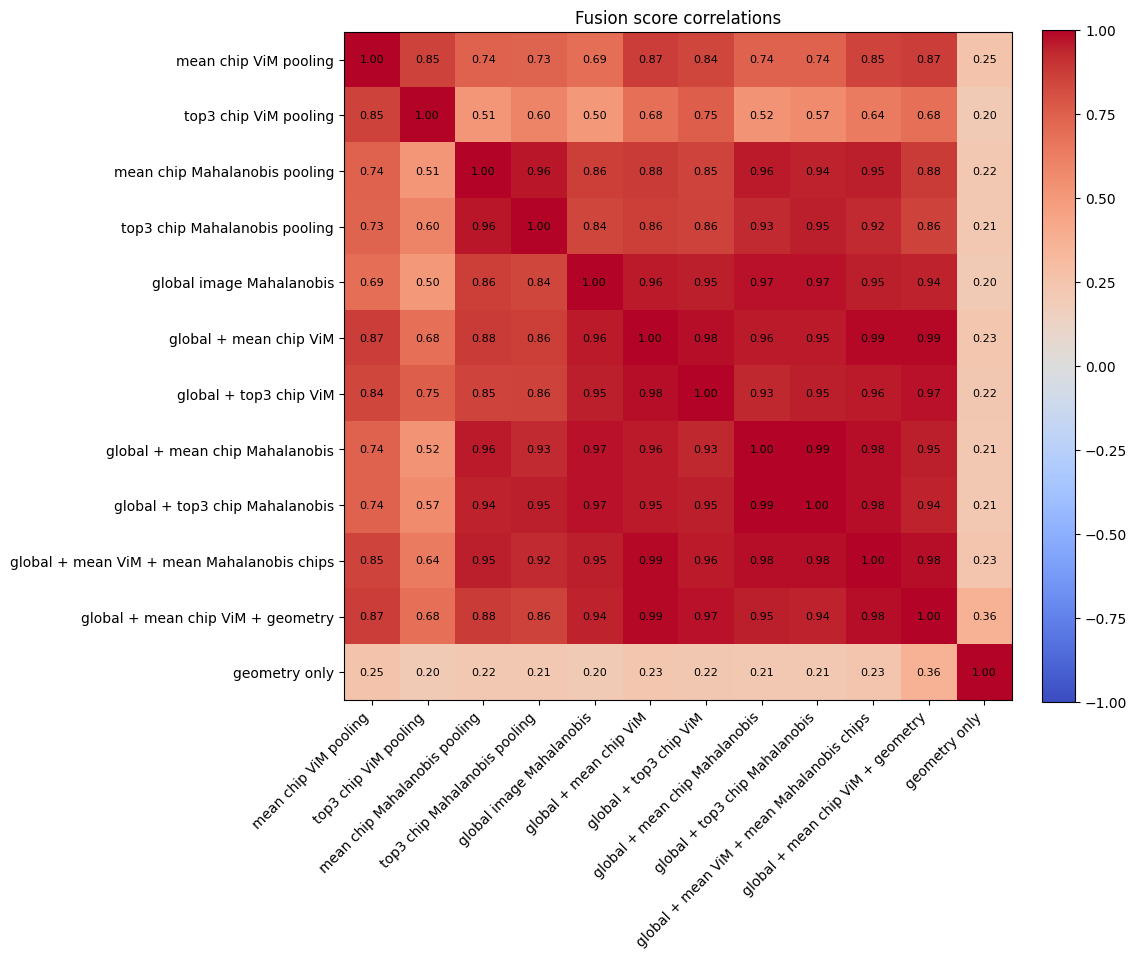

In [40]:
corr_names = list(fusion_scores)
corr = np.full((len(corr_names), len(corr_names)), np.nan, dtype=np.float64)
for i, a_name in enumerate(corr_names):
    for j, b_name in enumerate(corr_names):
        mask = fusion_mask & np.isfinite(fusion_scores[a_name]) & np.isfinite(fusion_scores[b_name])
        if np.sum(mask) >= 2:
            corr[i, j] = np.corrcoef(fusion_scores[a_name][mask], fusion_scores[b_name][mask])[0, 1]

fig, ax = plt.subplots(figsize=(0.7 * len(corr_names) + 3, 0.7 * len(corr_names) + 2))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(corr_names)), corr_names, rotation=45, ha="right")
ax.set_yticks(range(len(corr_names)), corr_names)
for i in range(len(corr_names)):
    for j in range(len(corr_names)):
        if np.isfinite(corr[i, j]):
            ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_title("Fusion score correlations")
fig.tight_layout()
plt.show()


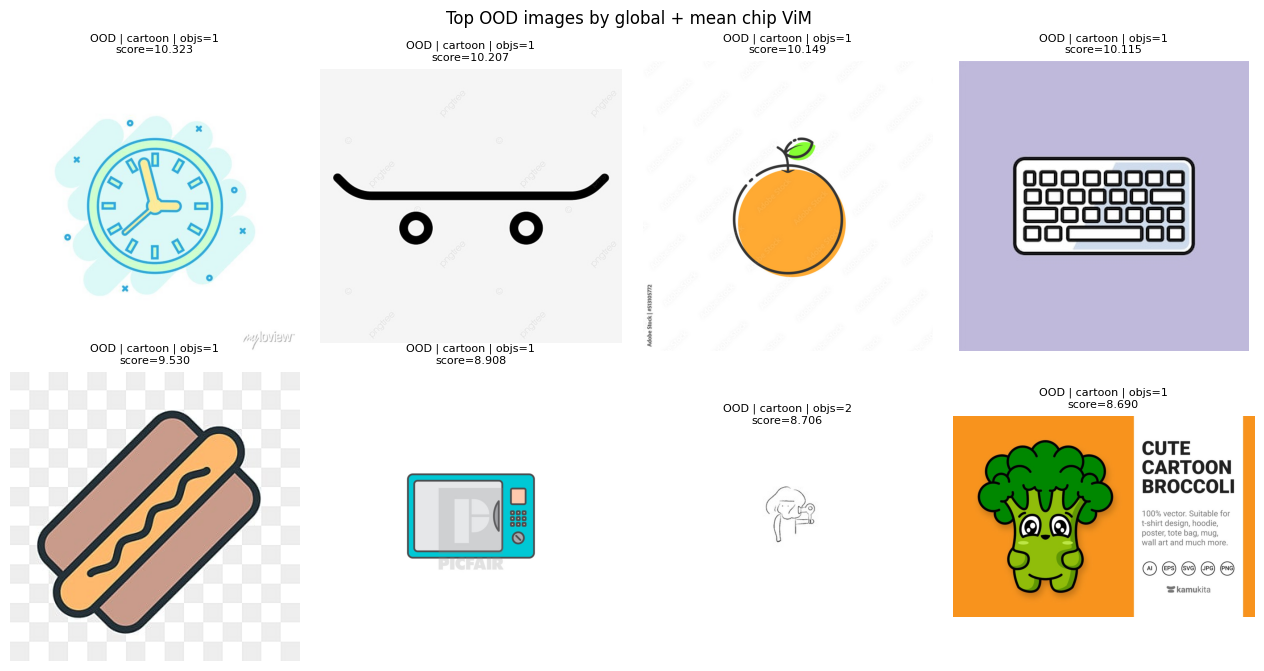

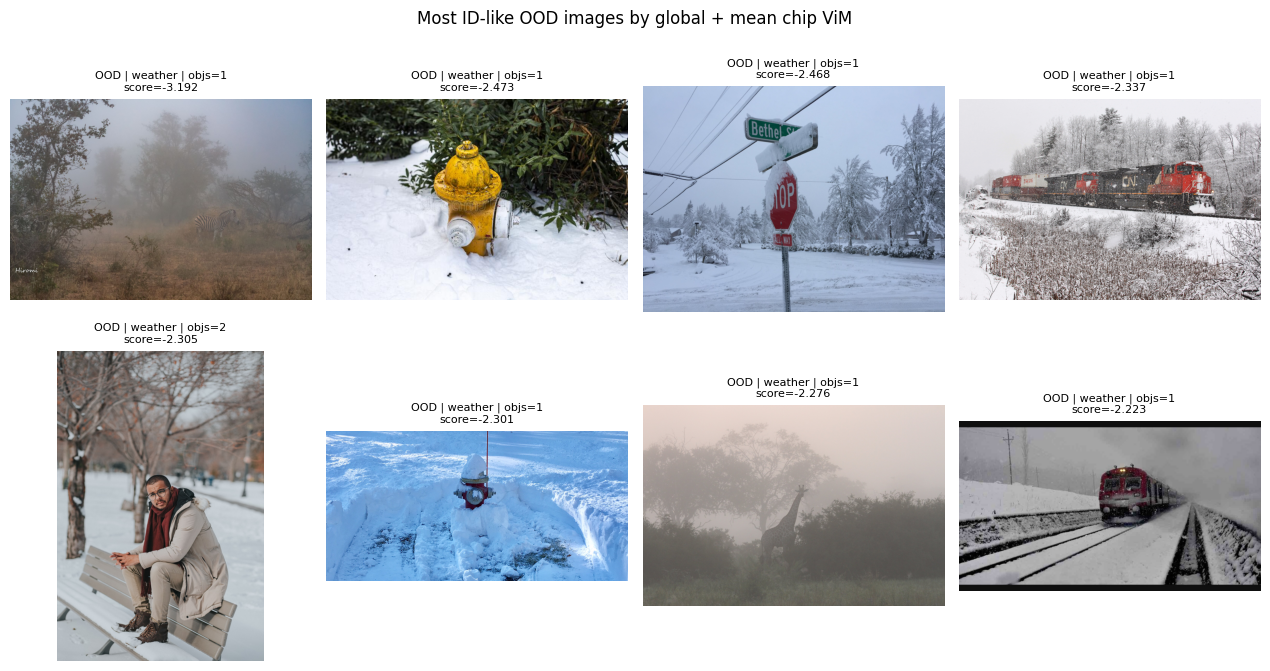

In [41]:
def _rank_indices(scores, *, direction="ood", truth=None, top_k=RANK_TOP_K):
    mask = fusion_mask & np.isfinite(scores)
    if truth == "id":
        mask &= image_ood_labels == 0
    elif truth == "ood":
        mask &= image_ood_labels == 1
    idx = np.nonzero(mask)[0]
    order = np.argsort(scores[idx])
    if direction == "ood":
        order = order[::-1]
    return idx[order[:top_k]]


def show_images(indices, scores, title):
    n = len(indices)
    if n == 0:
        print(f"No images to show for: {title}")
        return
    ncols = min(4, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.4 * nrows), squeeze=False)
    for pos, img_idx in enumerate(indices):
        img_idx = int(img_idx)
        ax = axes[pos // ncols][pos % ncols]
        ax.imshow(Image.open(image_paths[img_idx]).convert("RGB"))
        ax.axis("off")
        truth = "OOD" if image_ood_labels[img_idx] else "ID"
        ax.set_title(
            f"{truth} | {image_group[img_idx]} | objs={image_object_count[img_idx]}\nscore={scores[img_idx]:.3f}",
            fontsize=8,
        )
    for pos in range(n, nrows * ncols):
        axes[pos // ncols][pos % ncols].set_visible(False)
    fig.suptitle(title, fontsize=12)
    fig.tight_layout()
    plt.show()


primary_fusion_name = "global + mean chip ViM"
idx = _rank_indices(fusion_scores[primary_fusion_name], direction="ood", truth="ood")
show_images(idx, fusion_scores[primary_fusion_name], f"Top OOD images by {primary_fusion_name}")

idx = _rank_indices(fusion_scores[primary_fusion_name], direction="id", truth="ood")
show_images(idx, fusion_scores[primary_fusion_name], f"Most ID-like OOD images by {primary_fusion_name}")


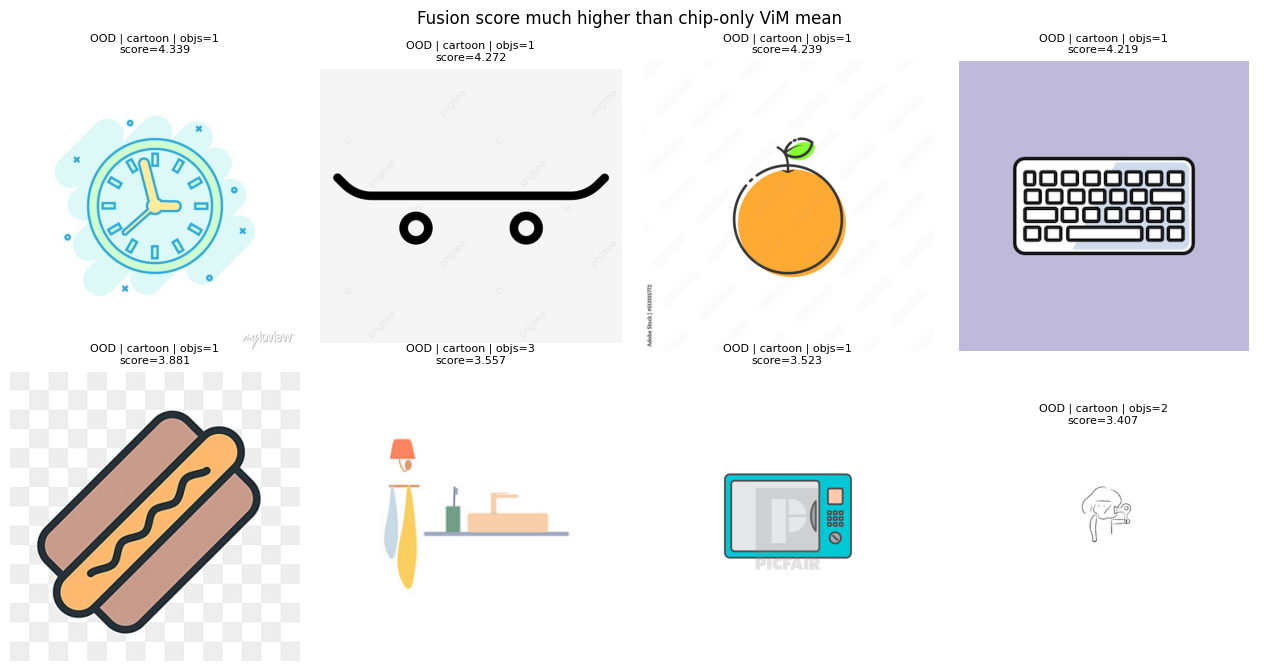

image=000000000318 | group=cartoon | truth=OOD | objects=1 | global=1452.437 | vim_mean=1.000 | mahal_mean=799.971 | geometry=2.052 | disagreement=+4.339
image=000000000993 | group=cartoon | truth=OOD | objects=1 | global=1438.063 | vim_mean=1.000 | mahal_mean=998.513 | geometry=3.166 | disagreement=+4.272
image=000000000401 | group=cartoon | truth=OOD | objects=1 | global=1430.886 | vim_mean=1.000 | mahal_mean=1099.964 | geometry=2.386 | disagreement=+4.239
image=000000000014 | group=cartoon | truth=OOD | objects=1 | global=1426.597 | vim_mean=1.000 | mahal_mean=1006.842 | geometry=0.992 | disagreement=+4.219
image=000000001977 | group=cartoon | truth=OOD | objects=1 | global=1354.018 | vim_mean=1.000 | mahal_mean=1095.172 | geometry=1.806 | disagreement=+3.881
image=000000001637 | group=cartoon | truth=OOD | objects=3 | global=1232.537 | vim_mean=0.832 | mahal_mean=655.646 | geometry=3.332 | disagreement=+3.557
image=000000000603 | group=cartoon | truth=OOD | objects=1 | global=1276.

In [42]:
disagreement = _zscore_on_id(fusion_scores[primary_fusion_name], id_cal_mask) - _zscore_on_id(chip_mean_scores, id_cal_mask)
idx = _rank_indices(disagreement, direction="ood", truth=None)
show_images(idx, disagreement, "Fusion score much higher than chip-only ViM mean")

for img_idx in idx:
    img_idx = int(img_idx)
    truth = "OOD" if image_ood_labels[img_idx] else "ID"
    print(
        f"image={image_ids[img_idx]} | group={image_group[img_idx]} | truth={truth} | "
        f"objects={image_object_count[img_idx]} | global={global_scores[img_idx]:.3f} | "
        f"vim_mean={chip_mean_scores[img_idx]:.3f} | mahal_mean={chip_mahal_mean_scores[img_idx]:.3f} | "
        f"geometry={geometry_scores[img_idx]:.3f} | disagreement={disagreement[img_idx]:+.3f}"
    )
